# 📈 EUR/USD Forex Forecasting — LSTM & TCN
**Applied Forecasting Methods | Deep Learning Track**

| # | Section | Description |
|---|---------|-------------|
| 0 | Setup | Install packages, imports, seeds |
| 1 | Data Loading | Load & inspect `eurusd_hour.csv` |
| 2 | EDA | Price series, returns, seasonality, ACF/PACF, ADF |
| 3 | Pre-processing | Feature engineering, scaling, sequence creation, splits |
| 4 | LSTM | Baseline → Optuna tuning → Final model → Evaluation |
| 5 | TCN | Baseline → Optuna tuning → Final model → Evaluation |
| 6 | Comparison | Side-by-side metrics, residual analysis, combined forecast plot |

> **Setup:** Upload `eurusd_hour.csv` to `/content/` in Colab (Files panel → Upload), then run all cells.

---
## 0 · Setup & Installs

In [9]:
# ── Install extra packages ────────────────────────────────────────────────────
!pip install optuna optuna-integration[tensorflow] --quiet
print('✓ Packages installed')

✓ Packages installed


In [10]:
# ── Core imports ──────────────────────────────────────────────────────────────
import warnings, os, gc, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    Conv1D, Add, Activation, LayerNormalization,
    GlobalAveragePooling1D, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Tuning
import optuna
from optuna.integration import TFKerasPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13
})

print(f'✓ TF version : {tf.__version__}')
print(f'✓ GPU devices: {tf.config.list_physical_devices("GPU")}')

✓ TF version : 2.19.0
✓ GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 1 · Data Loading

In [11]:
# ── Load CSV ──────────────────────────────────────────────────────────────────
CSV_PATH = '/content/eurusd_hour.csv.xlsx'

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        'eurusd_hour.csv not found.\n'
        'In Colab: click Files (folder icon on left) → Upload → select eurusd_hour.csv'
    )

df_raw = pd.read_excel(CSV_PATH)

# Combine Date + Time → datetime index
df_raw['Datetime'] = pd.to_datetime(df_raw['Date'].astype(str) + ' ' + df_raw['Time'].astype(str))
df_raw = df_raw.set_index('Datetime').sort_index()
df_raw.drop(columns=['Date', 'Time'], inplace=True)

print(f'Raw shape  : {df_raw.shape}')
print(f'Date range : {df_raw.index.min()} → {df_raw.index.max()}')
print(f'Columns    : {list(df_raw.columns)}')
print(f'Missing    :')
print(df_raw.isnull().sum())
df_raw.head()

Raw shape  : (93084, 10)
Date range : 2005-05-02 00:00:00 → 2020-04-29 22:00:00
Columns    : ['BO', 'BH', 'BL', 'BC', 'BCh', 'AO', 'AH', 'AL', 'AC', 'ACh']
Missing    :
BO     0
BH     0
BL     0
BC     0
BCh    0
AO     0
AH     0
AL     0
AC     0
ACh    0
dtype: int64


,BO,BH,BL,BC,BCh,AO,AH,AL,AC,ACh
Datetime,,,,,,,,,,
2005-05-02 00:00:00,1.2852,1.2852,1.2840,1.2844,-0.0008,1.2854,1.2854,1.2842,1.2846,-0.0008
2005-05-02 01:00:00,1.2844,1.2848,1.2839,1.2842,-0.0002,1.2846,1.2850,1.2841,1.2844,-0.0002
2005-05-02 02:00:00,1.2843,1.2854,1.2841,1.2851,0.0008,1.2845,1.2856,1.2843,1.2853,0.0008
2005-05-02 03:00:00,1.2851,1.2859,1.2850,1.2851,0.0000,1.2853,1.2861,1.2852,1.2853,0.0000
2005-05-02 04:00:00,1.2852,1.2859,1.2849,1.2855,0.0003,1.2854,1.2861,1.2851,1.2857,0.0003


In [12]:
# ── Column legend ─────────────────────────────────────────────────────────────
# BO/BH/BL/BC/BCh = Bid Open/High/Low/Close/Change
# AO/AH/AL/AC/ACh = Ask Open/High/Low/Close/Change

# Use Bid Close (BC) as the main price series
df = df_raw[['BC']].rename(columns={'BC': 'Close'}).copy()
df.dropna(inplace=True)

# Remove duplicate index entries
df = df[~df.index.duplicated(keep='first')]

# Forward-fill any remaining gaps (weekend gaps, holidays)
df = df.asfreq('H', method='ffill')

print(f'Clean series: {len(df):,} hourly bars')
print(f'Price range : {df.Close.min():.5f} – {df.Close.max():.5f}')
df.describe()

Clean series: 131,447 hourly bars
Price range : 1.03555 – 1.60139


,Close
count,131447.000000
mean,1.265137
std,0.127062
min,1.035550
25%,1.139375
50%,1.273060
75%,1.357530
max,1.601390


---
## 2 · Exploratory Data Analysis (EDA)

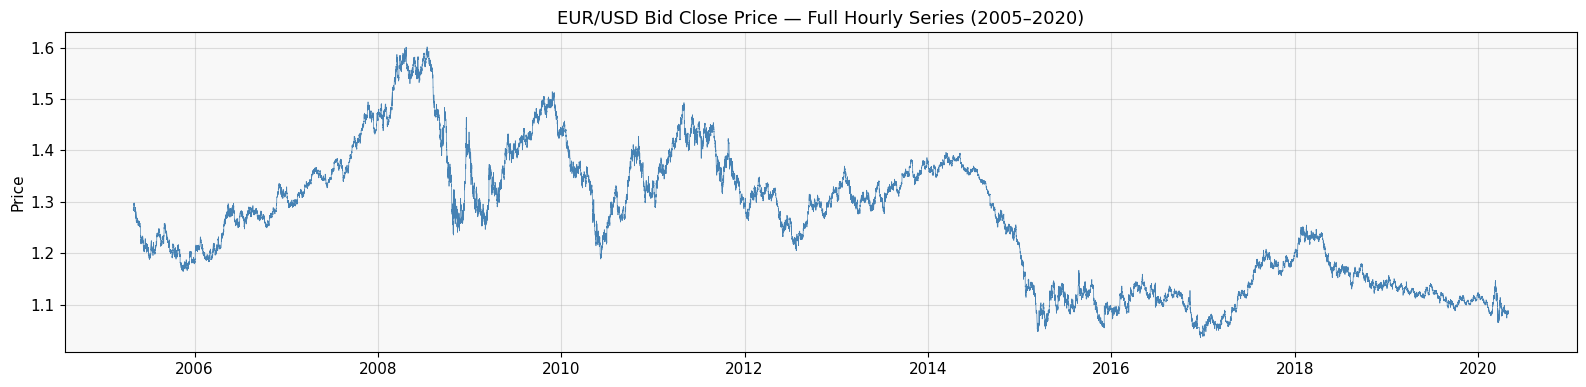

In [13]:
# ── 2.1 Full price series ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df['Close'], lw=0.5, color='steelblue')
ax.set_title('EUR/USD Bid Close Price — Full Hourly Series (2005–2020)')
ax.set_ylabel('Price')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('fig_eda_price.png', dpi=120, bbox_inches='tight')
plt.show()

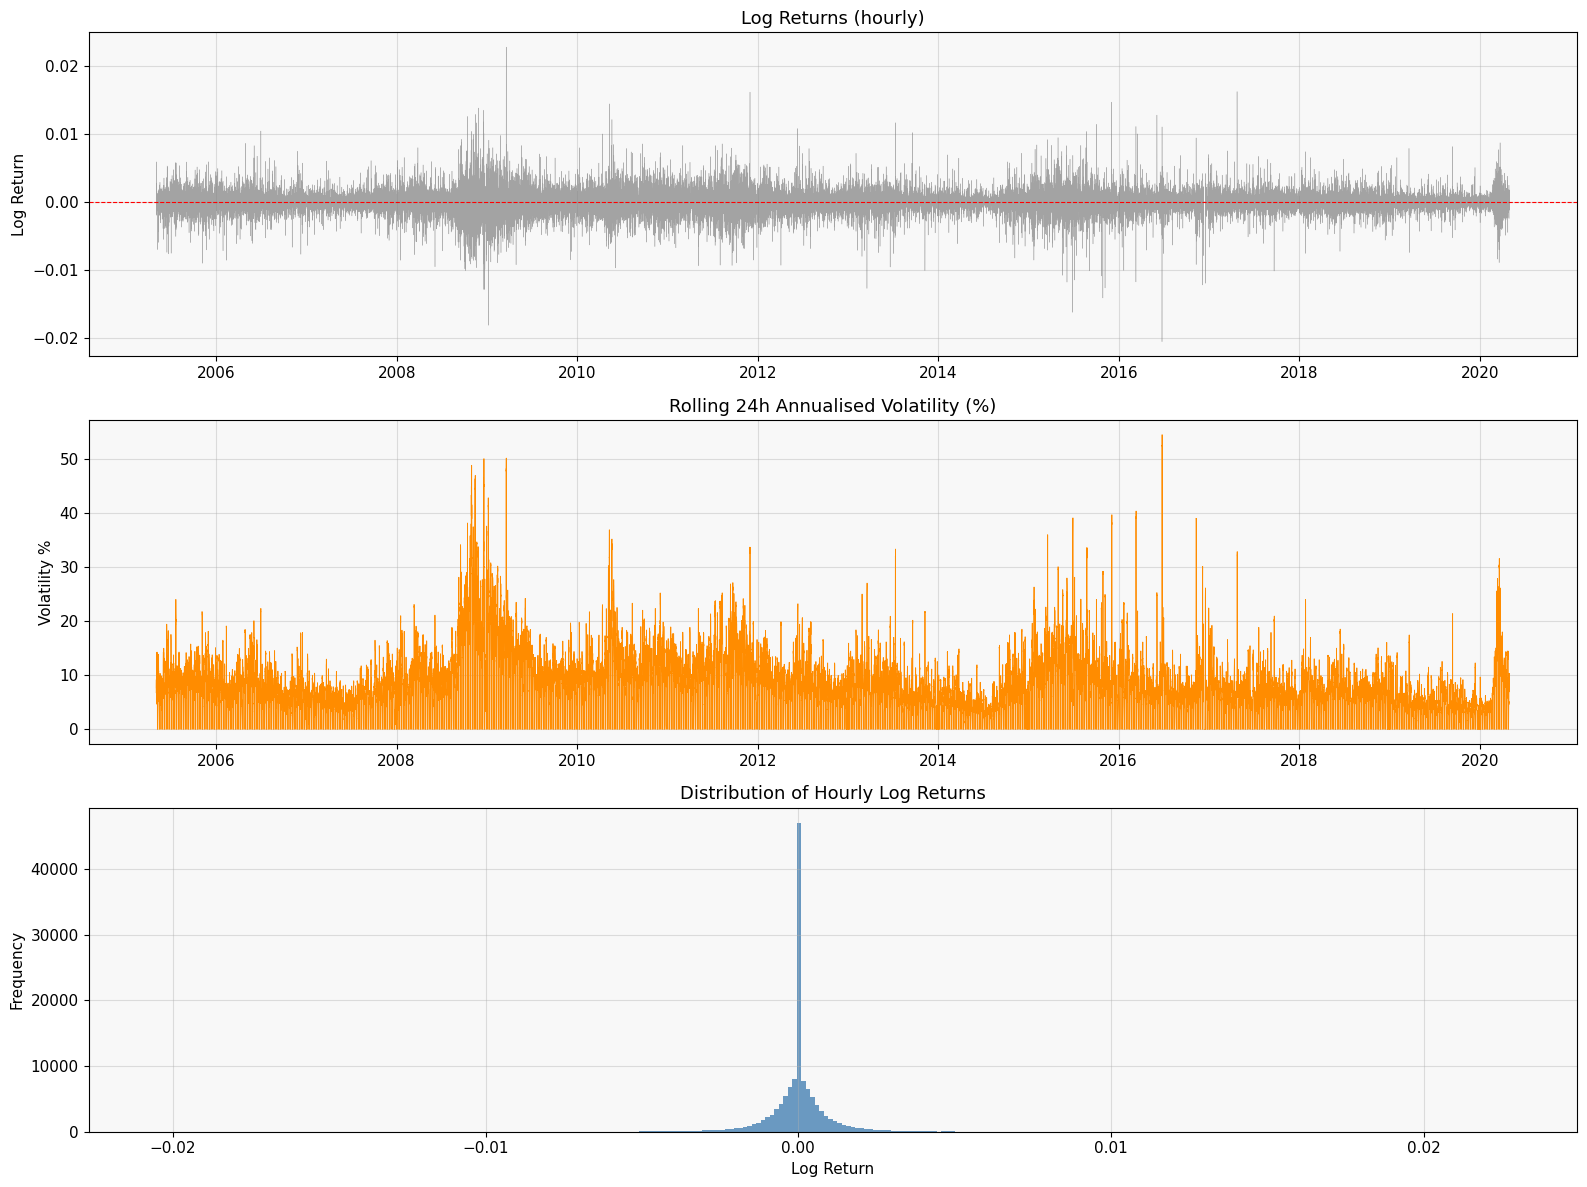

In [14]:
# ── 2.2 Returns & Volatility ──────────────────────────────────────────────────
df['Log_Return']    = np.log(df['Close'] / df['Close'].shift(1))
df['Pct_Return']    = df['Close'].pct_change()
df['Rolling_Std24'] = df['Log_Return'].rolling(24).std()   # 24-hour rolling vol
df['Rolling_Mu24']  = df['Close'].rolling(24).mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(df.index, df['Log_Return'], lw=0.3, color='gray', alpha=0.7)
axes[0].axhline(0, color='red', lw=0.8, ls='--')
axes[0].set_title('Log Returns (hourly)')
axes[0].set_ylabel('Log Return')

axes[1].plot(df.index, df['Rolling_Std24'] * np.sqrt(8760) * 100, lw=0.6, color='darkorange')
axes[1].set_title('Rolling 24h Annualised Volatility (%)')
axes[1].set_ylabel('Volatility %')

axes[2].hist(df['Log_Return'].dropna(), bins=300, color='steelblue', edgecolor='none', alpha=0.8)
axes[2].set_title('Distribution of Hourly Log Returns')
axes[2].set_xlabel('Log Return')
axes[2].set_ylabel('Frequency')

for ax in axes[:2]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('fig_eda_returns.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
# ── 2.3 Descriptive statistics ────────────────────────────────────────────────
desc = df[['Close', 'Log_Return']].describe()

from scipy import stats as sp_stats
lr = df['Log_Return'].dropna()
print(f'Skewness  : {lr.skew():.4f}')
print(f'Kurtosis  : {lr.kurtosis():.4f}  (excess; normal=0)')
print(f'Jarque-Bera p-value: {sp_stats.jarque_bera(lr).pvalue:.2e}')
print()
desc

Skewness  : 0.0285
Kurtosis  : 21.6106  (excess; normal=0)
Jarque-Bera p-value: 0.00e+00



,Close,Log_Return
count,131447.000000,131446.000000
mean,1.265137,-0.000001
std,0.127062,0.001025
min,1.035550,-0.020538
25%,1.139375,-0.000245
50%,1.273060,0.000000
75%,1.357530,0.000246
max,1.601390,0.022742


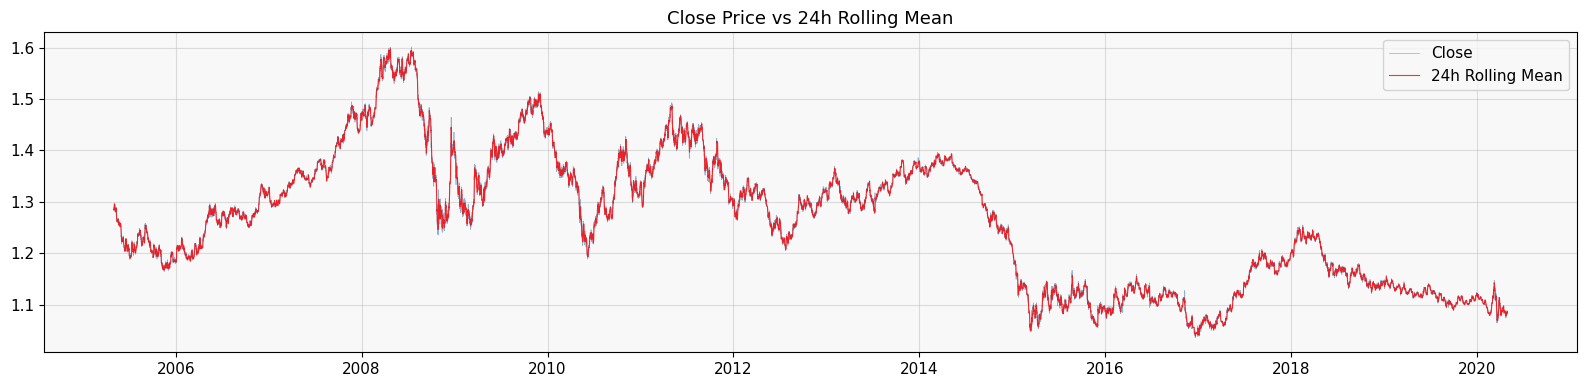

In [16]:
# ── 2.4 Rolling Mean vs Actual (stationarity visual) ─────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df['Close'],         lw=0.5, color='steelblue', alpha=0.6, label='Close')
ax.plot(df.index, df['Rolling_Mu24'],  lw=0.8, color='red',       alpha=0.8, label='24h Rolling Mean')
ax.set_title('Close Price vs 24h Rolling Mean')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

In [17]:
# ── 2.5 ADF Stationarity Test ─────────────────────────────────────────────────
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    stat, pval = result[0], result[1]
    label = '✓ STATIONARY' if pval < 0.05 else '✗ NON-STATIONARY'
    print(f'{name:<30}  ADF: {stat:9.4f}   p-value: {pval:.6f}   → {label}')

print('Augmented Dickey-Fuller Tests')
print('─' * 75)
adf_test(df['Close'],      'Close (price levels)')
adf_test(df['Log_Return'], 'Log Returns')
adf_test(df['Close'].diff(), 'First Difference of Price')

Augmented Dickey-Fuller Tests
───────────────────────────────────────────────────────────────────────────
Close (price levels)            ADF:   -1.6173   p-value: 0.474134   → ✗ NON-STATIONARY
Log Returns                     ADF:  -65.2793   p-value: 0.000000   → ✓ STATIONARY
First Difference of Price       ADF:  -42.5498   p-value: 0.000000   → ✓ STATIONARY


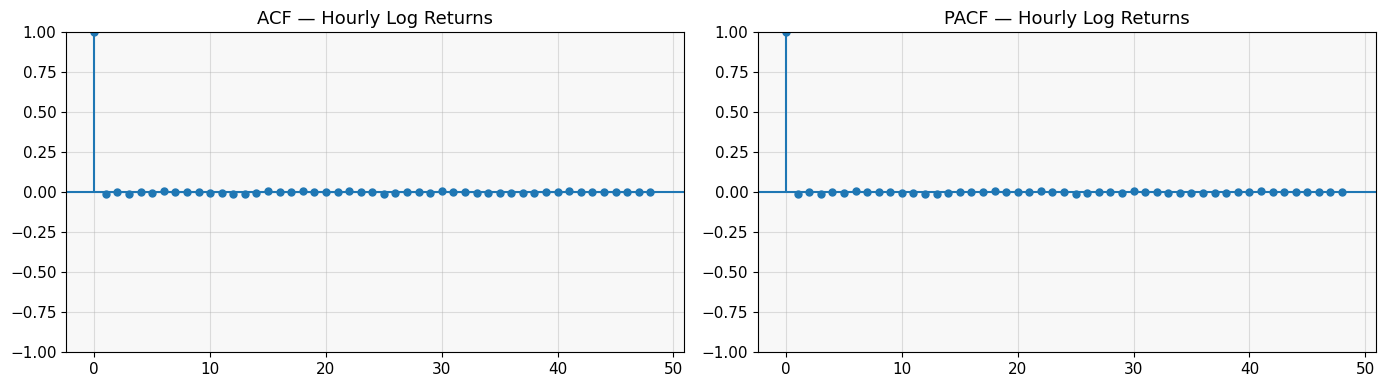

In [18]:
# ── 2.6 ACF / PACF of Log Returns ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( df['Log_Return'].dropna(), lags=48, ax=axes[0])
plot_pacf(df['Log_Return'].dropna(), lags=48, ax=axes[1])
axes[0].set_title('ACF — Hourly Log Returns')
axes[1].set_title('PACF — Hourly Log Returns')
plt.tight_layout()
plt.savefig('fig_acf_pacf.png', dpi=120, bbox_inches='tight')
plt.show()

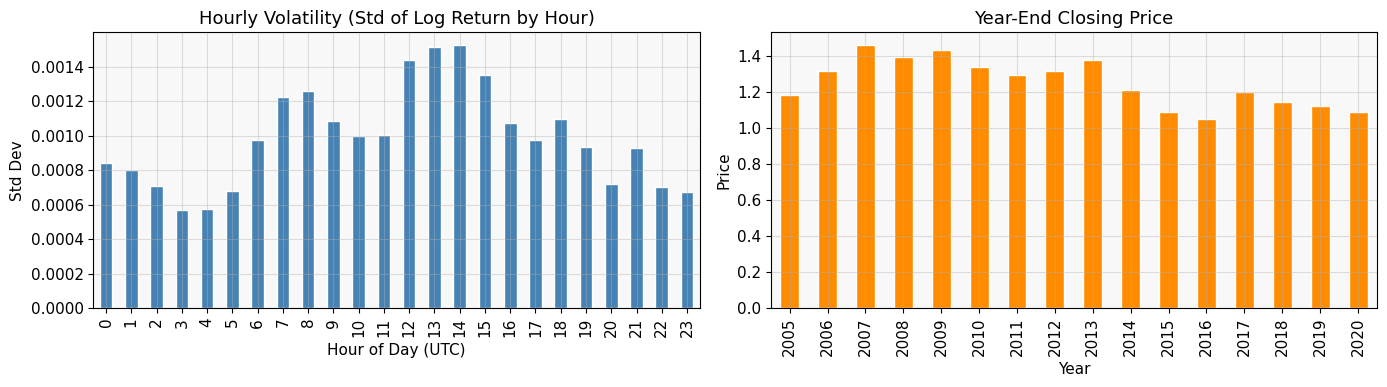

In [19]:
# ── 2.7 Hour-of-day & year-on-year patterns ───────────────────────────────────
df_eda = df.copy()
df_eda['Hour']  = df_eda.index.hour
df_eda['Year']  = df_eda.index.year
df_eda['Month'] = df_eda.index.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_eda.groupby('Hour')['Log_Return'].std().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Hourly Volatility (Std of Log Return by Hour)')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('Std Dev')

df_eda.groupby('Year')['Close'].last().plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Year-End Closing Price')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.savefig('fig_seasonality.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3 · Pre-processing

In [20]:
# ── 3.1 Feature engineering ───────────────────────────────────────────────────
# Build a feature matrix. We use BC (Close) + derived technical features.

feat = df[['Close']].copy()
feat['Log_Return']    = np.log(feat['Close'] / feat['Close'].shift(1))
feat['Return_Lag1']   = feat['Log_Return'].shift(1)
feat['Return_Lag2']   = feat['Log_Return'].shift(2)
feat['Return_Lag3']   = feat['Log_Return'].shift(3)
feat['Rolling_Mu24']  = feat['Close'].rolling(24).mean()
feat['Rolling_Std24'] = feat['Log_Return'].rolling(24).std()
feat['Rolling_Mu72']  = feat['Close'].rolling(72).mean()
feat['Momentum24']    = feat['Close'] - feat['Close'].shift(24)   # 24h momentum
feat['Hour_Sin']      = np.sin(2 * np.pi * feat.index.hour / 24)  # cyclical hour encoding
feat['Hour_Cos']      = np.cos(2 * np.pi * feat.index.hour / 24)

feat.dropna(inplace=True)

TARGET_COL = 'Close'
FEATURE_COLS = [c for c in feat.columns if c != TARGET_COL]

print(f'Features   : {FEATURE_COLS}')
print(f'Total rows : {len(feat):,}')
feat.head(3)

Features   : ['Log_Return', 'Return_Lag1', 'Return_Lag2', 'Return_Lag3', 'Rolling_Mu24', 'Rolling_Std24', 'Rolling_Mu72', 'Momentum24', 'Hour_Sin', 'Hour_Cos']
Total rows : 131,376


,Close,Log_Return,Return_Lag1,Return_Lag2,Return_Lag3,Rolling_Mu24,Rolling_Std24,Rolling_Mu72,Momentum24,Hour_Sin,Hour_Cos
Datetime,,,,,,,,,,,
2005-05-04 23:00:00,1.2943,-0.000386,-0.000386,0.000595,0.000155,1.294647,0.001312,1.288850,0.00647,-0.258819,0.965926
2005-05-05 00:00:00,1.2937,-0.000464,-0.000386,-0.000386,0.000595,1.294859,0.001316,1.288979,0.00507,0.000000,1.000000
2005-05-05 01:00:00,1.2934,-0.000232,-0.000464,-0.000386,-0.000386,1.294741,0.000499,1.289107,-0.00283,0.258819,0.965926


In [21]:
# ── 3.2 Train / Val / Test split (70 / 15 / 15) — NO shuffle ─────────────────
n      = len(feat)
n_tr   = int(n * 0.70)
n_val  = int(n * 0.85)   # 70–85 = val, 85–100 = test

train_df = feat.iloc[:n_tr]
val_df   = feat.iloc[n_tr:n_val]
test_df  = feat.iloc[n_val:]

print('─' * 55)
print(f'TRAIN  : {len(train_df):>7,} rows  {train_df.index[0].date()} → {train_df.index[-1].date()}')
print(f'VAL    : {len(val_df):>7,} rows  {val_df.index[0].date()}  → {val_df.index[-1].date()}')
print(f'TEST   : {len(test_df):>7,} rows  {test_df.index[0].date()}  → {test_df.index[-1].date()}')
print('─' * 55)

───────────────────────────────────────────────────────
TRAIN  :  91,963 rows  2005-05-04 → 2015-10-31
VAL    :  19,706 rows  2015-10-31  → 2018-01-29
TEST   :  19,707 rows  2018-01-29  → 2020-04-29
───────────────────────────────────────────────────────


In [22]:
# ── 3.3 MinMax scaling (fit on train only) ────────────────────────────────────
# Scale all columns together; inverse-transform only the target column.

all_cols = [TARGET_COL] + FEATURE_COLS

scaler_all = MinMaxScaler(feature_range=(0, 1))
scaler_all.fit(train_df[all_cols])

# Separate target scaler for easy inverse-transform
scaler_target = MinMaxScaler(feature_range=(0, 1))
scaler_target.fit(train_df[[TARGET_COL]])

train_scaled = scaler_all.transform(train_df[all_cols])
val_scaled   = scaler_all.transform(val_df[all_cols])
test_scaled  = scaler_all.transform(test_df[all_cols])

# Target column index
target_idx = all_cols.index(TARGET_COL)

print(f'Train scaled shape : {train_scaled.shape}')
print(f'Val   scaled shape : {val_scaled.shape}')
print(f'Test  scaled shape : {test_scaled.shape}')
print(f'Target column idx  : {target_idx}')

Train scaled shape : (91963, 11)
Val   scaled shape : (19706, 11)
Test  scaled shape : (19707, 11)
Target column idx  : 0


In [23]:
# ── 3.4 Sequence creation ─────────────────────────────────────────────────────
LOOKBACK = 48   # 48 hours of history → predict next close

def create_sequences(data_scaled, lookback, target_idx=0):
    """
    Returns:
      X : (samples, lookback, n_features)
      y : (samples, 1)  — scaled target at t+1
    """
    X, y = [], []
    for i in range(lookback, len(data_scaled)):
        X.append(data_scaled[i - lookback : i, :])  # all features
        y.append(data_scaled[i, target_idx])          # target only
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

X_train, y_train = create_sequences(train_scaled, LOOKBACK, target_idx)
X_val,   y_val   = create_sequences(val_scaled,   LOOKBACK, target_idx)
X_test,  y_test  = create_sequences(test_scaled,  LOOKBACK, target_idx)

# Dates aligned to the prediction target (t+1)
train_dates = train_df.index[LOOKBACK:]
val_dates   = val_df.index[LOOKBACK:]
test_dates  = test_df.index[LOOKBACK:]

N_FEATURES = X_train.shape[2]

print(f'X_train : {X_train.shape}  y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}    y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}   y_test  : {y_test.shape}')
print(f'N_FEATURES = {N_FEATURES}')

X_train : (91915, 48, 11)  y_train : (91915, 1)
X_val   : (19658, 48, 11)    y_val   : (19658, 1)
X_test  : (19659, 48, 11)   y_test  : (19659, 1)
N_FEATURES = 11


In [24]:
# ── 3.5 Shared evaluation utility ─────────────────────────────────────────────
def evaluate_model(model_name, y_true_scaled, y_pred_scaled, silent=False):
    """
    Inverse-transforms predictions → original price scale, computes metrics.
    Returns dict with metric values and arrays.
    """
    y_true = scaler_target.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler_target.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2    = r2_score(y_true, y_pred)
    da    = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100  # directional accuracy

    if not silent:
        print(f'\n{"="*50}')
        print(f'  {model_name} — TEST SET METRICS')
        print(f'{"="*50}')
        print(f'  RMSE               : {rmse:.6f}')
        print(f'  MAE                : {mae:.6f}')
        print(f'  MAPE               : {mape:.4f}%')
        print(f'  R²                 : {r2:.6f}')
        print(f'  Directional Acc.   : {da:.2f}%')
        print(f'{"="*50}')

    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape,
            'R2': r2, 'DA': da, 'y_true': y_true, 'y_pred': y_pred}


def get_callbacks(patience=10, lr_patience=5):
    return [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=lr_patience, min_lr=1e-7, verbose=0)
    ]


def plot_forecast(model_name, dates, y_true, y_pred, color='tomato', save_name=None):
    """Actual vs predicted, last 1500 observations."""
    N = min(1500, len(y_true))
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    axes[0].plot(dates[-N:], y_true[-N:], color='black', lw=0.8, label='Actual')
    axes[0].plot(dates[-N:], y_pred[-N:], color=color, lw=0.8, alpha=0.85, label=f'{model_name} Predicted')
    axes[0].set_title(f'{model_name} — Actual vs Predicted (test set, last {N} bars)')
    axes[0].legend(); axes[0].set_ylabel('EUR/USD')

    residuals = y_true[-N:] - y_pred[-N:]
    axes[1].plot(dates[-N:], residuals, color=color, lw=0.5, alpha=0.7)
    axes[1].axhline(0, color='black', lw=0.8, ls='--')
    axes[1].set_title(f'{model_name} — Residuals')
    axes[1].set_ylabel('Residual')

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()


ALL_RESULTS = []  # will collect metric dicts from both models
print('✓ Utilities defined')

✓ Utilities defined


---
## 4 · LSTM Model

**Architecture flow:** Input (48 × 10) → LSTM(units, return_seq) → Dropout → LSTM(units) → Dropout → Dense(32) → Dense(1)

Three stages:
1. **Baseline** — fixed, reasonable hyperparameters
2. **Optuna Tuning** — search over units, layers, dropout, LR, lookback, batch size
3. **Final Model** — retrain with best params on train+val, evaluate on test

In [25]:
# ── 4.1 LSTM Baseline ─────────────────────────────────────────────────────────
def build_lstm_baseline(lookback, n_features):
    model = Sequential([
        Input(shape=(lookback, n_features)),
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='LSTM_Baseline')
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

lstm_baseline = build_lstm_baseline(LOOKBACK, N_FEATURES)
lstm_baseline.summary()

Model: "LSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 128)        │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,201 (481.25 KB)

 Trainable params: 123,201 (481.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0020 - mae: 0.0283 - val_loss: 1.2870e-04 - val_mae: 0.0092 - learning_rate: 0.0010
Epoch 2/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 4.0488e-04 - mae: 0.0147 - val_loss: 5.9772e-04 - val_mae: 0.0231 - learning_rate: 0.0010
Epoch 3/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 2.2689e-04 - mae: 0.0110 - val_loss: 1.8244e-04 - val_mae: 0.0104 - learning_rate: 0.0010
Epoch 4/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 1.7031e-04 - mae: 0.0095 - val_loss: 3.8386e-04 - val_mae: 0.0171 - learning_rate: 0.0010
Epoch 5/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 1.2762e-04 - mae: 0.0082 - val_loss: 2.0269e-04 - val_mae: 0.0122 - learning_rate: 0.0010
Epoch 6/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 1.1333e-04 - mae: 0.0077 - val_loss: 1.1395e-04 - val_mae: 0.0098 - learning_rate: 0.0010
Epoch 7/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 8.4948e-05 - mae: 0.0066 - va

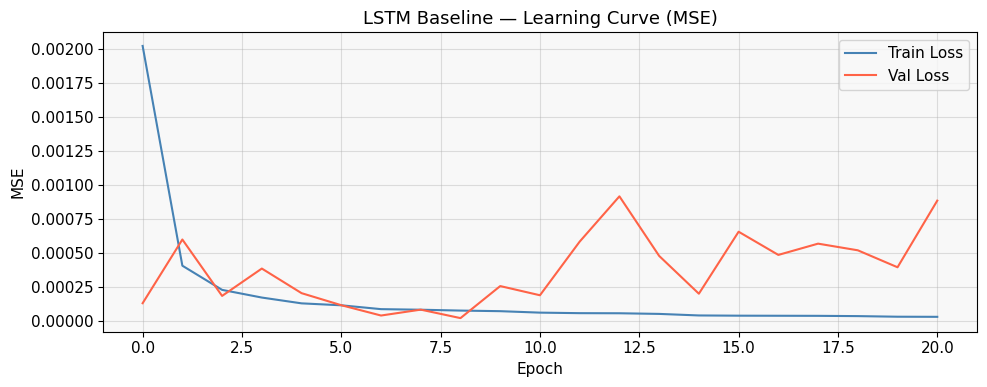


  LSTM Baseline — TEST SET METRICS
  RMSE               : 0.002973
  MAE                : 0.002256
  MAPE               : 0.1947%
  R²                 : 0.994662
  Directional Acc.   : 34.55%


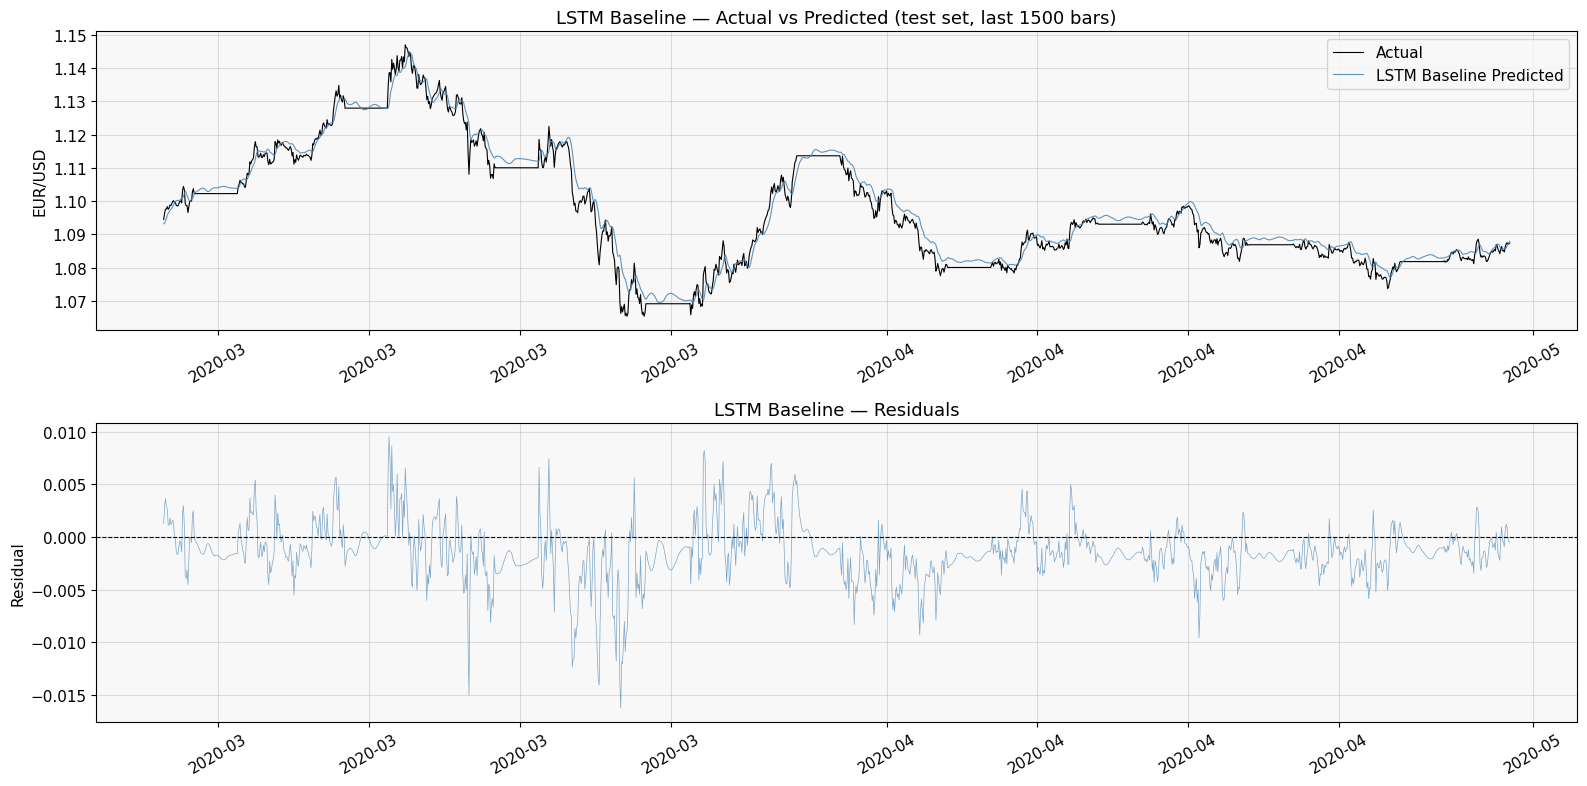

In [26]:
history_lstm_base = lstm_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=get_callbacks(patience=12),
    verbose=1
)

# Learning curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_lstm_base.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(history_lstm_base.history['val_loss'], label='Val Loss',   color='tomato')
ax.set_title('LSTM Baseline — Learning Curve (MSE)')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout(); plt.savefig('fig_lstm_base_curve.png', dpi=120); plt.show()

y_pred_lstm_base = lstm_baseline.predict(X_test, verbose=0)
res_lstm_base = evaluate_model('LSTM Baseline', y_test, y_pred_lstm_base)
plot_forecast('LSTM Baseline', test_dates[1:], res_lstm_base['y_true'][1:],
              res_lstm_base['y_pred'][1:], color='steelblue', save_name='fig_lstm_base_forecast.png')

In [27]:
# ── 4.2 Optuna Hyperparameter Tuning for LSTM ─────────────────────────────────
N_TRIALS_LSTM   = 30    # increase for better results (use 50+ on GPU)
EPOCHS_TUNE     = 25
PATIENCE_TUNE   = 6

def build_lstm_trial(trial, lookback, n_features):
    n_layers  = trial.suggest_int('n_lstm_layers', 1, 3)
    dropout   = trial.suggest_float('dropout', 0.05, 0.5)
    lr        = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    dense_u   = trial.suggest_categorical('dense_units', [16, 32, 64])

    model = Sequential(name='LSTM_Trial')
    model.add(Input(shape=(lookback, n_features)))

    for i in range(n_layers):
        units     = trial.suggest_int(f'lstm_units_{i}', 32, 256, step=32)
        ret_seq   = (i < n_layers - 1)
        model.add(LSTM(units, return_sequences=ret_seq))
        model.add(Dropout(dropout))

    model.add(Dense(dense_u, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mse')
    return model


def objective_lstm(trial):
    lookback   = trial.suggest_int('lookback', 24, 96, step=24)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])

    X_tr, y_tr = create_sequences(train_scaled, lookback, target_idx)
    X_vl, y_vl = create_sequences(val_scaled,   lookback, target_idx)

    model = build_lstm_trial(trial, lookback, N_FEATURES)

    cbs = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE_TUNE, restore_best_weights=True),
        TFKerasPruningCallback(trial, 'val_loss')
    ]
    model.fit(X_tr, y_tr, validation_data=(X_vl, y_vl),
              epochs=EPOCHS_TUNE, batch_size=batch_size,
              callbacks=cbs, verbose=0)

    val_loss = model.evaluate(X_vl, y_vl, verbose=0)
    del model; gc.collect()
    tf.keras.backend.clear_session()
    return val_loss


pruner_lstm = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
study_lstm  = optuna.create_study(direction='minimize', pruner=pruner_lstm,
                                   study_name='LSTM_tuning')
print(f'Running {N_TRIALS_LSTM} Optuna trials for LSTM...')
study_lstm.optimize(objective_lstm, n_trials=N_TRIALS_LSTM, show_progress_bar=True)

best_lstm = study_lstm.best_trial
print(f'\n✓ Best LSTM trial  #{best_lstm.number}')
print(f'  Val MSE : {best_lstm.value:.8f}')
print(f'  Params  : {best_lstm.params}')

Running 30 Optuna trials for LSTM...


  0%|          | 0/30 [00:00<?, ?it/s]


✓ Best LSTM trial  #13
  Val MSE : 0.00000632
  Params  : {'lookback': 24, 'batch_size': 64, 'n_lstm_layers': 1, 'dropout': 0.06119743311847157, 'lr': 0.0015882852872577322, 'dense_units': 16, 'lstm_units_0': 192}


In [28]:
# ── 4.3 Optuna visualisation ──────────────────────────────────────────────────
try:
    import plotly
    fig_imp = optuna.visualization.plot_param_importances(study_lstm)
    fig_imp.show()
    fig_hist = optuna.visualization.plot_optimization_history(study_lstm)
    fig_hist.show()
except Exception as e:
    print(f'Plotly visualisation skipped: {e}')

# Rank top-5 trials
trials_df = study_lstm.trials_dataframe().sort_values('value').head(5)
print('\nTop-5 LSTM trials:')
print(trials_df[['number', 'value'] + [c for c in trials_df.columns if 'params_' in c]].to_string(index=False))


Top-5 LSTM trials:
 number    value  params_batch_size  params_dense_units  params_dropout  params_lookback  params_lr  params_lstm_units_0  params_lstm_units_1  params_lstm_units_2  params_n_lstm_layers
     13 0.000006                 64                  16        0.061197               24   0.001588                  192                  NaN                  NaN                     1
     27 0.000006                 64                  16        0.140561               24   0.000201                  224                160.0                  NaN                     2
     17 0.000007                 64                  16        0.101899               48   0.001250                  192                  NaN                  NaN                     1
      4 0.000007                 64                  64        0.060087               24   0.000488                  192                  NaN                  NaN                     1
      3 0.000007                 64                  16

In [29]:
# ── 4.4 Final LSTM — retrain with best params ─────────────────────────────────
p = best_lstm.params
BEST_LB_LSTM = p['lookback']

# Rebuild sequences with best lookback
X_tr_f, y_tr_f = create_sequences(train_scaled, BEST_LB_LSTM, target_idx)
X_vl_f, y_vl_f = create_sequences(val_scaled,   BEST_LB_LSTM, target_idx)
X_te_f, y_te_f = create_sequences(test_scaled,   BEST_LB_LSTM, target_idx)
test_dates_f   = test_df.index[BEST_LB_LSTM:]

# Combine train+val for final training
X_trainval = np.concatenate([X_tr_f, X_vl_f], axis=0)
y_trainval = np.concatenate([y_tr_f, y_vl_f], axis=0)

tf.keras.backend.clear_session()
lstm_final = build_lstm_trial(best_lstm, BEST_LB_LSTM, N_FEATURES)
lstm_final._name = 'LSTM_Final'
lstm_final.summary()

history_lstm_final = lstm_final.fit(
    X_trainval, y_trainval,
    validation_data=(X_te_f, y_te_f),
    epochs=150,
    batch_size=p['batch_size'],
    callbacks=get_callbacks(patience=15),
    verbose=1
)

Model: "LSTM_Trial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 192)            │       156,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         3,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,777 (624.13 KB)

 Trainable params: 159,777 (624.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 8.1167e-04 - val_loss: 4.6047e-05 - learning_rate: 0.0016
Epoch 2/150
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 1.2810e-04 - val_loss: 1.5039e-05 - learning_rate: 0.0016
Epoch 3/150
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 9.5103e-05 - val_loss: 3.3641e-05 - learning_rate: 0.0016
Epoch 4/150
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 7.1685e-05 - val_loss: 2.1689e-05 - learning_rate: 0.0016
Epoch 5/150
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 5.6747e-05 - val_loss: 1.9506e-05 - learning_rate: 0.0016
Epoch 6/150
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 5.0894e-05 - val_loss: 2.7649e-05 - learning_rate: 0.0016
Epoch 7/150
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 3.3940e-05 - val_loss: 9.4022e-06 - learning_rate: 7.9414e-04
Epoch 8/150
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 3.4040e-05 - val_loss: 2.0726e-05 - learning_rate: 7.9414e-04
Epoch 9/150
1745

In [ ]:
# ── 4.5 LSTM Final — Evaluation ───────────────────────────────────────────────
# Learning curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_lstm_final.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(history_lstm_final.history['val_loss'], label='Test Loss',  color='tomato')
ax.set_title('LSTM Final — Learning Curve')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout(); plt.savefig('fig_lstm_final_curve.png', dpi=120); plt.show()

y_pred_lstm_final = lstm_final.predict(X_te_f, verbose=0)
res_lstm_final    = evaluate_model('LSTM (Tuned)', y_te_f, y_pred_lstm_final)
ALL_RESULTS.append({k: v for k, v in res_lstm_final.items() if k not in ['y_true', 'y_pred']})

plot_forecast('LSTM (Tuned)', test_dates_f[1:],
              res_lstm_final['y_true'][1:], res_lstm_final['y_pred'][1:],
              color='steelblue', save_name='fig_lstm_forecast.png')

In [ ]:
# ── 4.6 LSTM — Residual histogram & QQ plot ───────────────────────────────────
from scipy import stats as sp_stats

resid_lstm = res_lstm_final['y_true'] - res_lstm_final['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(resid_lstm, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='red', lw=1)
axes[0].set_title('LSTM Residuals — Histogram')
axes[0].set_xlabel('Residual')

sp_stats.probplot(resid_lstm, dist='norm', plot=axes[1])
axes[1].set_title('LSTM Residuals — Q-Q Plot')

plt.tight_layout()
plt.savefig('fig_lstm_residuals.png', dpi=120)
plt.show()

print(f'Residual mean : {resid_lstm.mean():.6f}')
print(f'Residual std  : {resid_lstm.std():.6f}')

---
## 5 · TCN (Temporal Convolutional Network)

A **TCN** replaces recurrence with **dilated causal convolutions** + **residual skip connections**.
Each residual block doubles the dilation rate so the effective receptive field grows exponentially:

```
Input
 └─► [Dilated CausalConv → LayerNorm → ReLU → Dropout] × 2  ──► residual_add
                                                         ↑
                                                  1×1 Conv (match channels)
```

Dilations: 1, 2, 4, 8, 16, 32 → receptive field = 2 × kernel_size × (1+2+4+8+16+32) = 63 × k

In [32]:
# ── 5.1 TCN architecture blocks ───────────────────────────────────────────────
def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    """
    One TCN residual block with two dilated causal conv layers.
    """
    residual = x

    # Branch 1: first conv
    out = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding='causal',
        activation='linear',
        use_bias=True
    )(x)
    out = LayerNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)

    # Branch 2: second conv
    out = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding='causal',
        activation='linear',
        use_bias=True
    )(out)
    out = LayerNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)

    # Skip connection: 1×1 conv to match channels if needed
    if residual.shape[-1] != filters:
        residual = Conv1D(filters=filters, kernel_size=1, padding='same')(residual)

    return Add()([out, residual])


def build_tcn(lookback, n_features, n_blocks=6,
              filters=64, kernel_size=3, dropout_rate=0.2, lr=1e-3, name='TCN'):
    """
    Full TCN model.
    n_blocks  : number of residual blocks (dilation doubles each block)
    filters   : number of conv filters per block
    kernel_size: conv kernel size
    """
    inp = Input(shape=(lookback, n_features))
    x   = inp

    for i in range(n_blocks):
        dilation = 2 ** i   # 1, 2, 4, 8, 16, 32, ...
        x = tcn_residual_block(x, filters, kernel_size, dilation, dropout_rate)

    # Take last time-step output
    x = x[:, -1, :]           # (batch, filters)
    x = Dense(32, activation='relu')(x)
    out = Dense(1)(x)

    model = Model(inp, out, name=name)
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model

print('✓ TCN builder defined')

✓ TCN builder defined


In [33]:
# ── 5.2 TCN Baseline ──────────────────────────────────────────────────────────
tcn_baseline = build_tcn(
    lookback=LOOKBACK,
    n_features=N_FEATURES,
    n_blocks=6,
    filters=64,
    kernel_size=3,
    dropout_rate=0.2,
    lr=1e-3,
    name='TCN_Baseline'
)
tcn_baseline.summary()

Model: "TCN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 11)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 48, 64)    │      2,176 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 48, 64)    │        128 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 48, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 48, 64)    │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 64)    │        128 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 48, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 48, 64)    │        768 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 48, 64)    │     12,352 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 64)    │        128 │ conv1d_3[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 48, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 48, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 48, 64)    │     12,352 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 48, 64)    │        128 │ conv1d_4[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 48, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 48, 64)    │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 48, 64)    │          0 │ dropout_4[0][0],

 Total params: 142,465 (556.50 KB)

 Trainable params: 142,465 (556.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 52s 39ms/step - loss: 0.0864 - mae: 0.1567 - val_loss: 3.4675e-04 - val_mae: 0.0152 - learning_rate: 0.0010
Epoch 2/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0014 - mae: 0.0287 - val_loss: 2.9020e-04 - val_mae: 0.0150 - learning_rate: 0.0010
Epoch 3/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 3.9352e-04 - mae: 0.0149 - val_loss: 5.1325e-05 - val_mae: 0.0055 - learning_rate: 0.0010
Epoch 4/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 1.5652e-04 - mae: 0.0093 - val_loss: 6.1480e-05 - val_mae: 0.0068 - learning_rate: 0.0010
Epoch 5/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 7.5727e-05 - mae: 0.0064 - val_loss: 7.7158e-05 - val_mae: 0.0081 - learning_rate: 0.0010
Epoch 6/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5.1572e-05 - mae: 0.0053 - val_loss: 3.6790e-05 - val_mae: 0.0053 - learning_rate: 0.0010
Epoch 7/100
719/719 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 5.4561e-05 - mae: 0.0056 - 

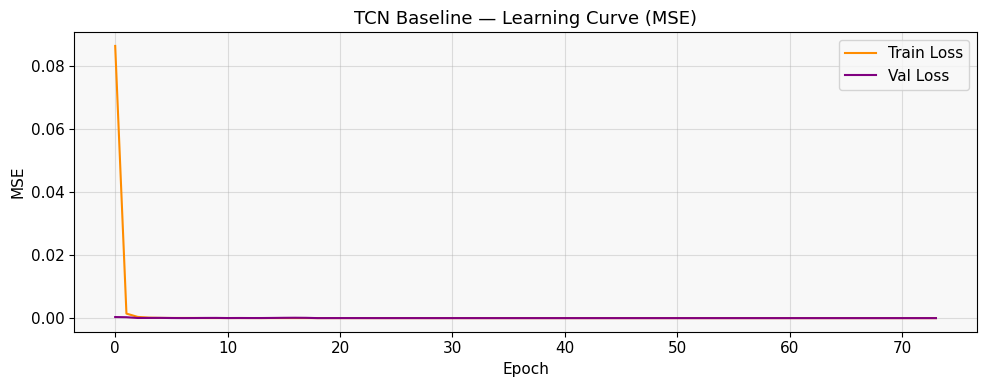


  TCN Baseline — TEST SET METRICS
  RMSE               : 0.001174
  MAE                : 0.000811
  MAPE               : 0.0710%
  R²                 : 0.999168
  Directional Acc.   : 34.09%


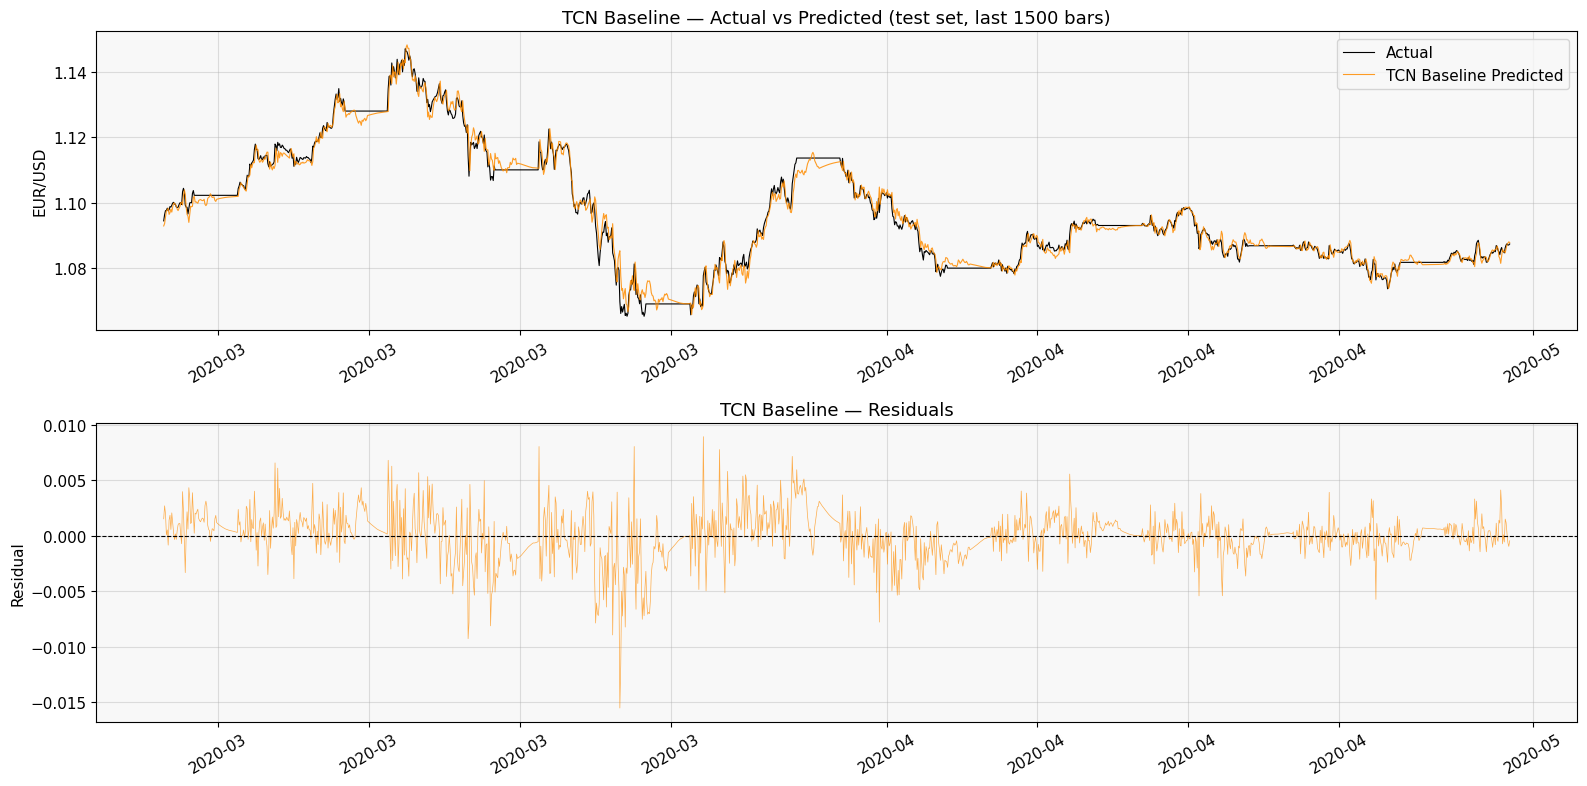

In [34]:
history_tcn_base = tcn_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=get_callbacks(patience=12),
    verbose=1
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_tcn_base.history['loss'],     label='Train Loss', color='darkorange')
ax.plot(history_tcn_base.history['val_loss'], label='Val Loss',   color='purple')
ax.set_title('TCN Baseline — Learning Curve (MSE)')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout(); plt.savefig('fig_tcn_base_curve.png', dpi=120); plt.show()

y_pred_tcn_base = tcn_baseline.predict(X_test, verbose=0)
res_tcn_base = evaluate_model('TCN Baseline', y_test, y_pred_tcn_base)
plot_forecast('TCN Baseline', test_dates[1:], res_tcn_base['y_true'][1:],
              res_tcn_base['y_pred'][1:], color='darkorange', save_name='fig_tcn_base_forecast.png')

In [ ]:
# ── 5.3 Optuna Hyperparameter Tuning for TCN ──────────────────────────────────
N_TRIALS_TCN  = 30

def objective_tcn(trial):
    lookback   = trial.suggest_int('lookback',    24, 96, step=24)
    filters    = trial.suggest_categorical('filters', [32, 64, 128])
    kernel_size= trial.suggest_int('kernel_size', 2, 5)
    n_blocks   = trial.suggest_int('n_blocks',    3, 7)
    dropout    = trial.suggest_float('dropout',   0.05, 0.40)
    lr         = trial.suggest_float('lr',        1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])

    X_tr, y_tr = create_sequences(train_scaled, lookback, target_idx)
    X_vl, y_vl = create_sequences(val_scaled,   lookback, target_idx)

    tf.keras.backend.clear_session()
    model = build_tcn(lookback, N_FEATURES, n_blocks,
                      filters, kernel_size, dropout, lr, name='TCN_trial')

    cbs = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE_TUNE, restore_best_weights=True),
        TFKerasPruningCallback(trial, 'val_loss')
    ]
    model.fit(X_tr, y_tr, validation_data=(X_vl, y_vl),
              epochs=EPOCHS_TUNE, batch_size=batch_size,
              callbacks=cbs, verbose=0)

    val_loss = model.evaluate(X_vl, y_vl, verbose=0)
    del model; gc.collect()
    tf.keras.backend.clear_session()
    return val_loss


pruner_tcn = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
study_tcn  = optuna.create_study(direction='minimize', pruner=pruner_tcn,
                                  study_name='TCN_tuning')
print(f'Running {N_TRIALS_TCN} Optuna trials for TCN...')
study_tcn.optimize(objective_tcn, n_trials=N_TRIALS_TCN, show_progress_bar=True)

best_tcn = study_tcn.best_trial
print(f'\n✓ Best TCN trial  #{best_tcn.number}')
print(f'  Val MSE : {best_tcn.value:.8f}')
print(f'  Params  : {best_tcn.params}')

In [ ]:
# ── 5.4 Optuna visualisation ──────────────────────────────────────────────────
try:
    fig_imp = optuna.visualization.plot_param_importances(study_tcn)
    fig_imp.show()
    fig_hist = optuna.visualization.plot_optimization_history(study_tcn)
    fig_hist.show()
except Exception as e:
    print(f'Plotly visualisation skipped: {e}')

trials_df_tcn = study_tcn.trials_dataframe().sort_values('value').head(5)
print('\nTop-5 TCN trials:')
print(trials_df_tcn[['number', 'value'] + [c for c in trials_df_tcn.columns if 'params_' in c]].to_string(index=False))

In [ ]:
# ── 5.5 Final TCN — retrain with best params ──────────────────────────────────
q = best_tcn.params
BEST_LB_TCN = q['lookback']

X_tr_q, y_tr_q = create_sequences(train_scaled, BEST_LB_TCN, target_idx)
X_vl_q, y_vl_q = create_sequences(val_scaled,   BEST_LB_TCN, target_idx)
X_te_q, y_te_q = create_sequences(test_scaled,   BEST_LB_TCN, target_idx)
test_dates_q   = test_df.index[BEST_LB_TCN:]

X_trainval_q = np.concatenate([X_tr_q, X_vl_q], axis=0)
y_trainval_q = np.concatenate([y_tr_q, y_vl_q], axis=0)

tf.keras.backend.clear_session()
tcn_final = build_tcn(
    lookback=BEST_LB_TCN,
    n_features=N_FEATURES,
    n_blocks=q['n_blocks'],
    filters=q['filters'],
    kernel_size=q['kernel_size'],
    dropout_rate=q['dropout'],
    lr=q['lr'],
    name='TCN_Final'
)
tcn_final.summary()

history_tcn_final = tcn_final.fit(
    X_trainval_q, y_trainval_q,
    validation_data=(X_te_q, y_te_q),
    epochs=150,
    batch_size=q['batch_size'],
    callbacks=get_callbacks(patience=15),
    verbose=1
)

In [ ]:
# ── 5.6 TCN Final — Evaluation ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_tcn_final.history['loss'],     label='Train Loss', color='darkorange')
ax.plot(history_tcn_final.history['val_loss'], label='Test Loss',  color='purple')
ax.set_title('TCN Final — Learning Curve')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend()
plt.tight_layout(); plt.savefig('fig_tcn_final_curve.png', dpi=120); plt.show()

y_pred_tcn_final = tcn_final.predict(X_te_q, verbose=0)
res_tcn_final    = evaluate_model('TCN (Tuned)', y_te_q, y_pred_tcn_final)
ALL_RESULTS.append({k: v for k, v in res_tcn_final.items() if k not in ['y_true', 'y_pred']})

plot_forecast('TCN (Tuned)', test_dates_q[1:],
              res_tcn_final['y_true'][1:], res_tcn_final['y_pred'][1:],
              color='darkorange', save_name='fig_tcn_forecast.png')

In [ ]:
# ── 5.7 TCN — Residual histogram & QQ plot ────────────────────────────────────
resid_tcn = res_tcn_final['y_true'] - res_tcn_final['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(resid_tcn, bins=80, color='darkorange', edgecolor='none', alpha=0.8)
axes[0].axvline(0, color='red', lw=1)
axes[0].set_title('TCN Residuals — Histogram')
axes[0].set_xlabel('Residual')

sp_stats.probplot(resid_tcn, dist='norm', plot=axes[1])
axes[1].set_title('TCN Residuals — Q-Q Plot')

plt.tight_layout()
plt.savefig('fig_tcn_residuals.png', dpi=120)
plt.show()

print(f'Residual mean : {resid_tcn.mean():.6f}')
print(f'Residual std  : {resid_tcn.std():.6f}')

---
## 6 · Model Comparison

In [ ]:
# ── 6.1 Metrics table ─────────────────────────────────────────────────────────
compare_df = pd.DataFrame(ALL_RESULTS).set_index('Model')
compare_df = compare_df[['RMSE', 'MAE', 'MAPE', 'R2', 'DA']]
compare_df.columns = ['RMSE', 'MAE', 'MAPE (%)', 'R²', 'Dir. Acc. (%)']

print('\n' + '═' * 65)
print('         FINAL MODEL COMPARISON — TEST SET')
print('═' * 65)
print(compare_df.round(6).to_string())
print('═' * 65)

# Highlight best values
best_rmse = compare_df['RMSE'].idxmin()
best_r2   = compare_df['R²'].idxmax()
best_da   = compare_df['Dir. Acc. (%)'].idxmax()
print(f'\n  Lowest RMSE   → {best_rmse}')
print(f'  Highest R²    → {best_r2}')
print(f'  Best Dir.Acc. → {best_da}')

In [ ]:
# ── 6.2 Bar-chart comparison ──────────────────────────────────────────────────
metrics_to_plot = ['RMSE', 'MAE', 'MAPE (%)', 'R²', 'Dir. Acc. (%)']
colors = ['steelblue', 'darkorange']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4))

for ax, metric in zip(axes, metrics_to_plot):
    vals   = compare_df[metric]
    bars   = ax.bar(vals.index, vals.values, color=colors[:len(vals)], edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=15, ha='right')

plt.suptitle('LSTM vs TCN — Test Set Metric Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_comparison_bar.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── 6.3 Combined forecast overlay (common test period) ────────────────────────
# Align to the shorter test set
min_n = min(len(res_lstm_final['y_true']), len(res_tcn_final['y_true']))
N_PLOT = min(min_n, 1500)

# Use test_dates from TCN (it may differ from LSTM due to different lookback)
td = test_dates_q[1:N_PLOT+1]
y_true_plot = res_tcn_final['y_true'][1:N_PLOT+1]
y_lstm_plot = res_lstm_final['y_true'][1:N_PLOT+1]  # same actual series, shown once
y_lstm_pred = res_lstm_final['y_pred'][1:N_PLOT+1]
y_tcn_pred  = res_tcn_final['y_pred'][1:N_PLOT+1]

# Handle potential length mismatch after alignment
n_common = min(len(td), len(y_lstm_pred), len(y_tcn_pred))
td, y_true_plot = td[:n_common], y_true_plot[:n_common]
y_lstm_pred, y_tcn_pred = y_lstm_pred[:n_common], y_tcn_pred[:n_common]

fig, ax = plt.subplots(figsize=(18, 6))
ax.plot(td, y_true_plot,  color='black',      lw=1.0, label='Actual',     zorder=3)
ax.plot(td, y_lstm_pred,  color='steelblue',  lw=0.8, alpha=0.85, label='LSTM (Tuned)', zorder=2)
ax.plot(td, y_tcn_pred,   color='darkorange', lw=0.8, alpha=0.85, label='TCN (Tuned)',  zorder=2)
ax.set_title('EUR/USD — Combined Forecast: LSTM vs TCN (Test Set)')
ax.set_ylabel('EUR/USD Price')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.savefig('fig_combined_forecast.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── 6.4 Scatter — Predicted vs Actual ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res, color, name in zip(
    axes,
    [res_lstm_final, res_tcn_final],
    ['steelblue', 'darkorange'],
    ['LSTM (Tuned)', 'TCN (Tuned)']
):
    yt, yp = res['y_true'], res['y_pred']
    ax.scatter(yt, yp, alpha=0.05, s=3, color=color)
    mn, mx = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1, label='Perfect fit')
    ax.set_title(f'{name} — Predicted vs Actual (R²={res["R2"]:.4f})')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend()

plt.tight_layout()
plt.savefig('fig_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── 6.5 Baseline vs Tuned comparison ─────────────────────────────────────────
# Add baseline results to compare improvement
base_results = []
for nm, y_pred, y_true in [
    ('LSTM Baseline', y_pred_lstm_base, y_test),
    ('TCN Baseline',  y_pred_tcn_base,  y_test)
]:
    r = evaluate_model(nm, y_true, y_pred, silent=True)
    base_results.append({k: v for k, v in r.items() if k not in ['y_true', 'y_pred']})

full_compare = pd.DataFrame(base_results + ALL_RESULTS).set_index('Model')
full_compare = full_compare[['RMSE', 'MAE', 'MAPE', 'R2', 'DA']]
full_compare.columns = ['RMSE', 'MAE', 'MAPE (%)', 'R²', 'Dir. Acc. (%)']

print('\n' + '═' * 70)
print('      BASELINE vs TUNED — Full Comparison Table')
print('═' * 70)
print(full_compare.round(6).to_string())
print('═' * 70)

In [ ]:
# ── 6.6 Save models & best hyperparameters ────────────────────────────────────
lstm_final.save('lstm_final.keras')
tcn_final.save('tcn_final.keras')

import json
best_params = {
    'LSTM': best_lstm.params,
    'TCN' : best_tcn.params
}
with open('best_hyperparams.json', 'w') as f:
    json.dump(best_params, f, indent=2)

print('✓ Models saved : lstm_final.keras, tcn_final.keras')
print('✓ Best params  : best_hyperparams.json')
print(json.dumps(best_params, indent=2))

In [ ]:
# ── 6.7 Download all outputs ──────────────────────────────────────────────────
from google.colab import files
import glob

outputs = (
    glob.glob('fig_*.png') +
    ['lstm_final.keras', 'tcn_final.keras', 'best_hyperparams.json']
)

print('Files available for download:')
for f in sorted(outputs):
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f'  {f:<45} {size_kb:8.1f} KB')

# Uncomment to download everything in one go:
# for f in outputs:
#     if os.path.exists(f):
#         files.download(f)

---
## Summary

| Stage | LSTM | TCN |
|-------|------|-----|
| **Architecture** | Stacked LSTM + Dense | Dilated causal Conv1D residual blocks |
| **Inductive bias** | Sequential memory via cell/hidden state | Causal + parallel via dilated convolutions |
| **Receptive field** | All history (gates control) | 2^n_blocks × kernel_size steps |
| **Tuning** | Optuna (units, layers, dropout, LR, lookback) | Optuna (filters, kernel, blocks, dropout, LR, lookback) |
| **Training** | 70% train, 15% val, 15% test | Same split |
| **Evaluation** | RMSE, MAE, MAPE, R², Dir. Acc. | Same metrics |

### Key design choices
- **No data leakage**: scaler fit on train only, no shuffle, val/test never seen during tuning
- **Multi-feature input**: price + log returns + lagged returns + rolling stats + cyclical hour encoding
- **Optuna pruning**: MedianPruner stops unpromising trials early
- **Final retraining**: best params applied on train+val combined for maximum data use

---
*Project: Applied Forecasting Methods — EUR/USD Deep Learning Track*